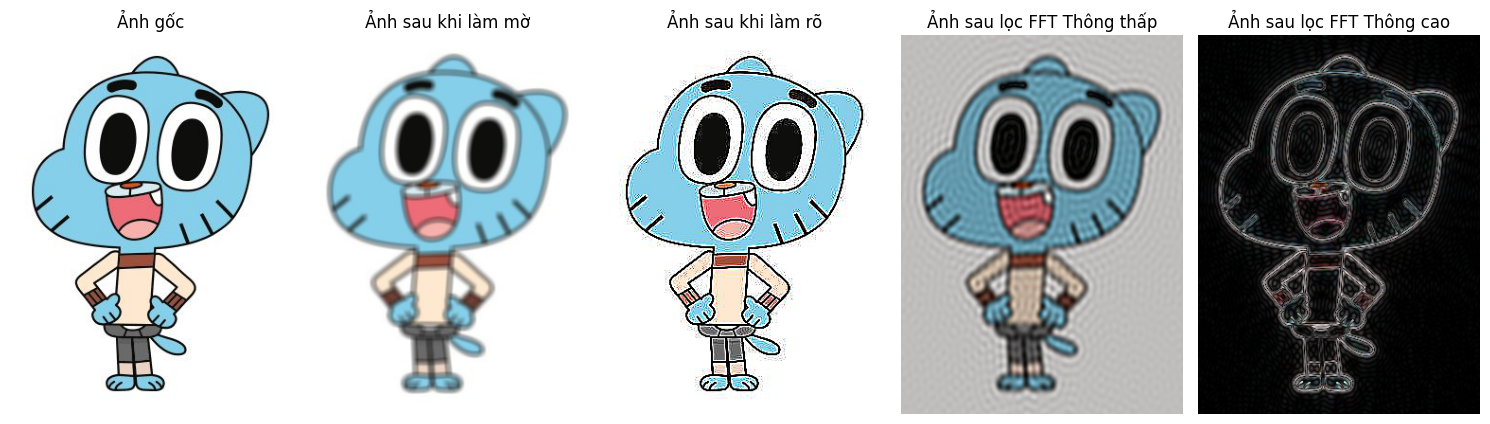

ĐÁNH GIÁ CHẤT LƯỢNG ẢNH SAU KHI LỌC
Lọc thông thấp        PSNR=   17.95 dB | SSIM=0.7664
Lọc thông cao         PSNR=   19.83 dB | SSIM=0.8525
Lọc thông thấp (FFT)  PSNR=   11.93 dB | SSIM=0.6326
Lọc thông cao (FFT)   PSNR=    1.47 dB | SSIM=-0.0287


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt        
from skimage.metrics import structural_similarity as ssim
from pathlib import Path

# uploaded=files.upload()                  
# for file_name in uploaded.keys():
#     print("Đã tải:", file_name)

# Nhập từ bàn phím:
IMAGE_PATH = Path(input("Nhập đường dẫn ảnh: ").strip())
file_name = str(IMAGE_PATH)

# Đọc dữ liệu
img=cv2.imread(file_name)
if img is None:
  print("Lỗi: không tìm thấy ảnh")

# DÙNG BỘ LỌC
# Làm mờ
blur=cv2.blur(img, (7,7))
# Làm rõ
kernel = np.array([[-1,-1,-1],
                   [-1, 9,-1],
                   [-1,-1,-1]]) #tạo mặt nạ
sharpened = cv2.filter2D(img, -1, kernel) #lấy tích chập

# DÙNG FFT
# Lọc thông thấp trong miền tần số (FFT)
f = np.fft.fft2(img) 
fshift = np.fft.fftshift(f) #dịch tâm phổ để tần số thắp nằm giữa, tần số cao nằm ở góc
rows, cols, ch = img.shape
b,g,r = cv2.split(img) #chia ảnh thành 3 kênh

def fft_lowpass(channel, radius=40):
    f = np.fft.fft2(channel)
    fshift = np.fft.fftshift(f)
    crow, ccol = rows//2, cols//2 #tọa độ tâm phổ
    mask = np.zeros((rows, cols), np.uint8) #tạo mask có cùng kích thước ảnh chặn mọi tần số
    cv2.circle(mask, (ccol, crow), radius, 1, -1) #vẽ đường tròn lấy toàn bộ phía trong
    fshift_lp = fshift * mask #nhân từng phần tử
    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_lp))) #biến đổi ngược về miền không gian
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX) #chuẩn hóa
    return img_back.astype(np.uint8)

b_lp = fft_lowpass(b, radius=40) #lọc kênh b
g_lp = fft_lowpass(g, radius=40) #lọc kênh g
r_lp = fft_lowpass(r, radius=40) #lọc kênh r
img_low = cv2.merge((b_lp, g_lp, r_lp)) #ghép kênh

# Lọc thông cao trong miền tần số (FFT)
def fft_highpass(channel, radius=40):
    f = np.fft.fft2(channel)
    fshift = np.fft.fftshift(f)
    rows, cols = channel.shape
    crow, ccol = rows//2, cols//2
    mask = np.ones((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), radius, 0, -1) #vẽ đường trong lấy phần bên ngoài
    fshift_hp = fshift * mask
    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_hp)))
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
    return img_back.astype(np.uint8)

b_hp = fft_highpass(b, radius=40)
g_hp = fft_highpass(g, radius=40)
r_hp = fft_highpass(r, radius=40)
img_high = cv2.merge((b_hp, g_hp, r_hp))

titles = ["Ảnh gốc", "Ảnh sau khi làm mờ", "Ảnh sau khi làm rõ", "Ảnh sau lọc FFT Thông thấp", "Ảnh sau lọc FFT Thông cao"]
images = [img, blur, sharpened, img_low, img_high]
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i], fontsize=12)
    plt.axis('off')
plt.tight_layout()
plt.show()

# TÍNH TOÁN CHỈ SỐ CHẤT LƯỢNG
def mse(imageA, imageB):
    imageA = cv2.resize(imageA, (imageB.shape[1], imageB.shape[0]))
    err = np.mean((imageA.astype("float") - imageB.astype("float")) ** 2)
    return err

def psnr(imageA, imageB):
    mse_value = mse(imageA, imageB)
    if mse_value == 0:
        return 100
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse_value))

def ssim_index(imageA, imageB):
    imageA = cv2.cvtColor(np.uint8(imageA), cv2.COLOR_BGR2GRAY)
    imageB = cv2.cvtColor(np.uint8(imageB), cv2.COLOR_BGR2GRAY)
    # thêm data_range để chạy ổn định trên skimage mới
    s = ssim(imageA, imageB, data_range=255)
    return s

def evaluate(ref, test, name):
    m = mse(ref, test)
    p = psnr(ref, test)
    s = ssim_index(ref, test)
    print(f"{name:20s}  PSNR={p:8.2f} dB | SSIM={s:6.4f}")

print("ĐÁNH GIÁ CHẤT LƯỢNG ẢNH SAU KHI LỌC")
evaluate(img, blur, "Lọc thông thấp")
evaluate(img, sharpened, "Lọc thông cao")
evaluate(img, img_low, "Lọc thông thấp (FFT)")
evaluate(img, img_high, "Lọc thông cao (FFT)")